In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from baseline_network import BaselineNetwork

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:679: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 840/840 [00:45<00:00, 18.55it/s]


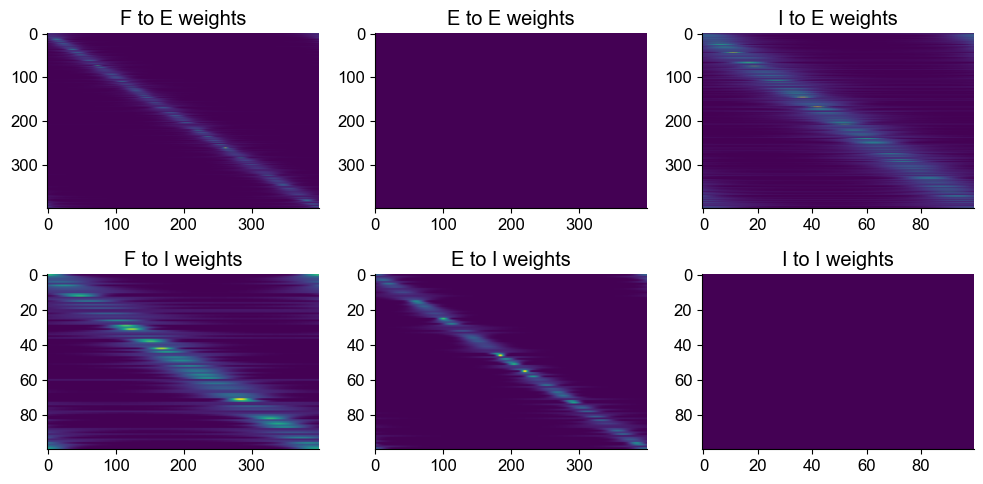

In [4]:
net = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="on", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, inh_scale=0.3, E_to_I_scale=0.2)
net.run()

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:747: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


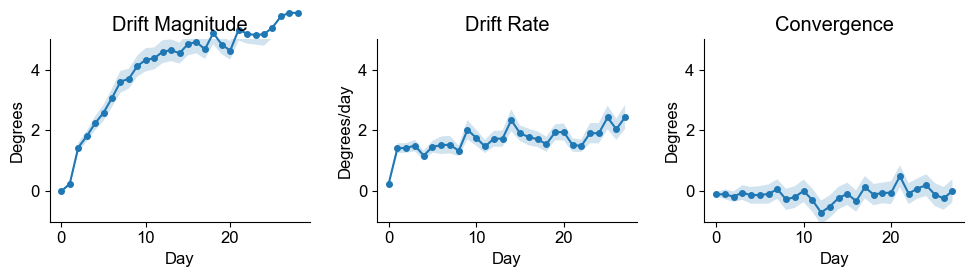

In [5]:
drift_mag, drift_rate, convergence = net.get_drift_metrics()
net.plot_drift_metrics(drift_mag, drift_rate, convergence)

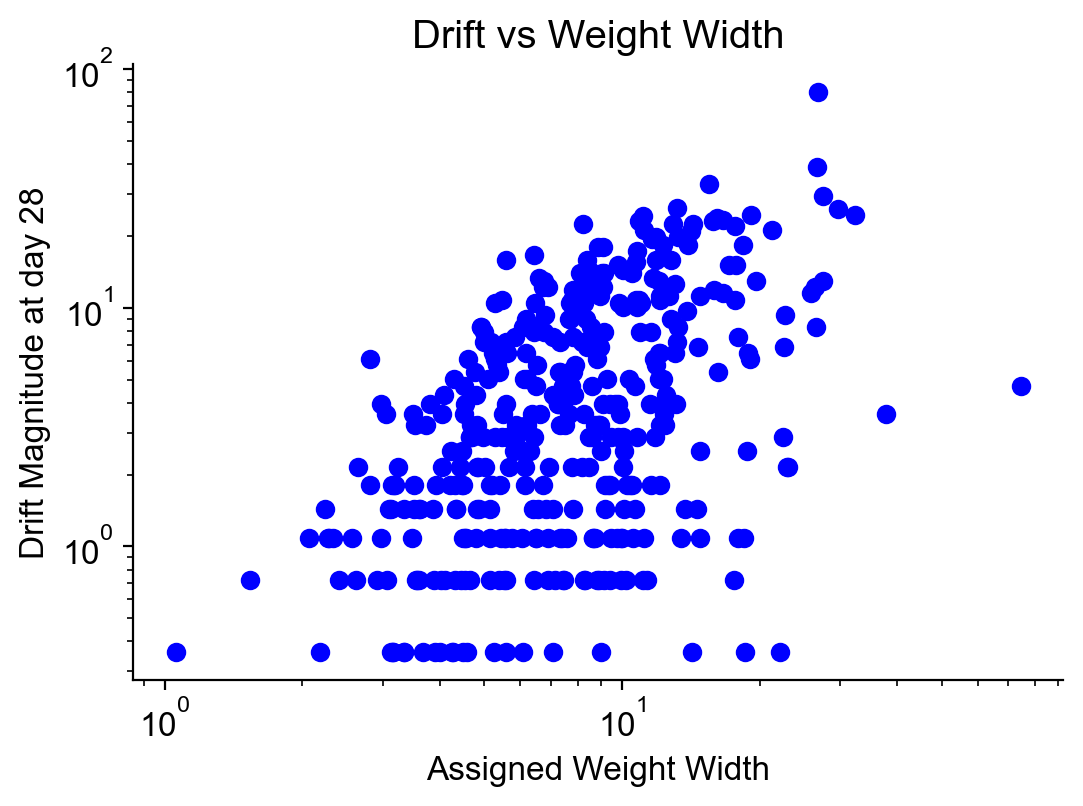

In [6]:
# Plot drift magnitude vs assigned weight width (vars_ef)

plt.figure(figsize=(6, 4), dpi=200)
plt.scatter(net.vars_ef, drift_mag[-1], color='blue')
plt.xlabel('Assigned Weight Width')
plt.ylabel('Drift Magnitude at day 28')
plt.title('Drift vs Weight Width')
plt.xscale('log')
plt.yscale('log')

plt.show()


/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:779: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


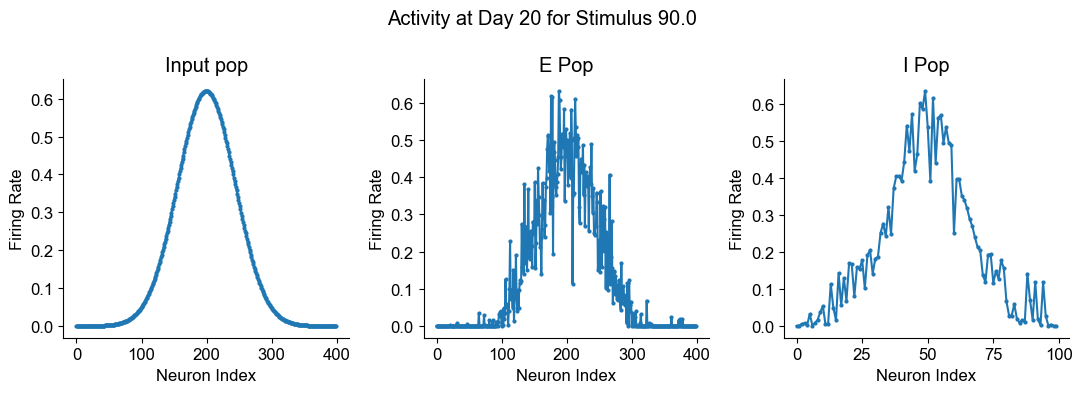

In [7]:
net.plot_activity_at_day(20, 90)

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:634: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


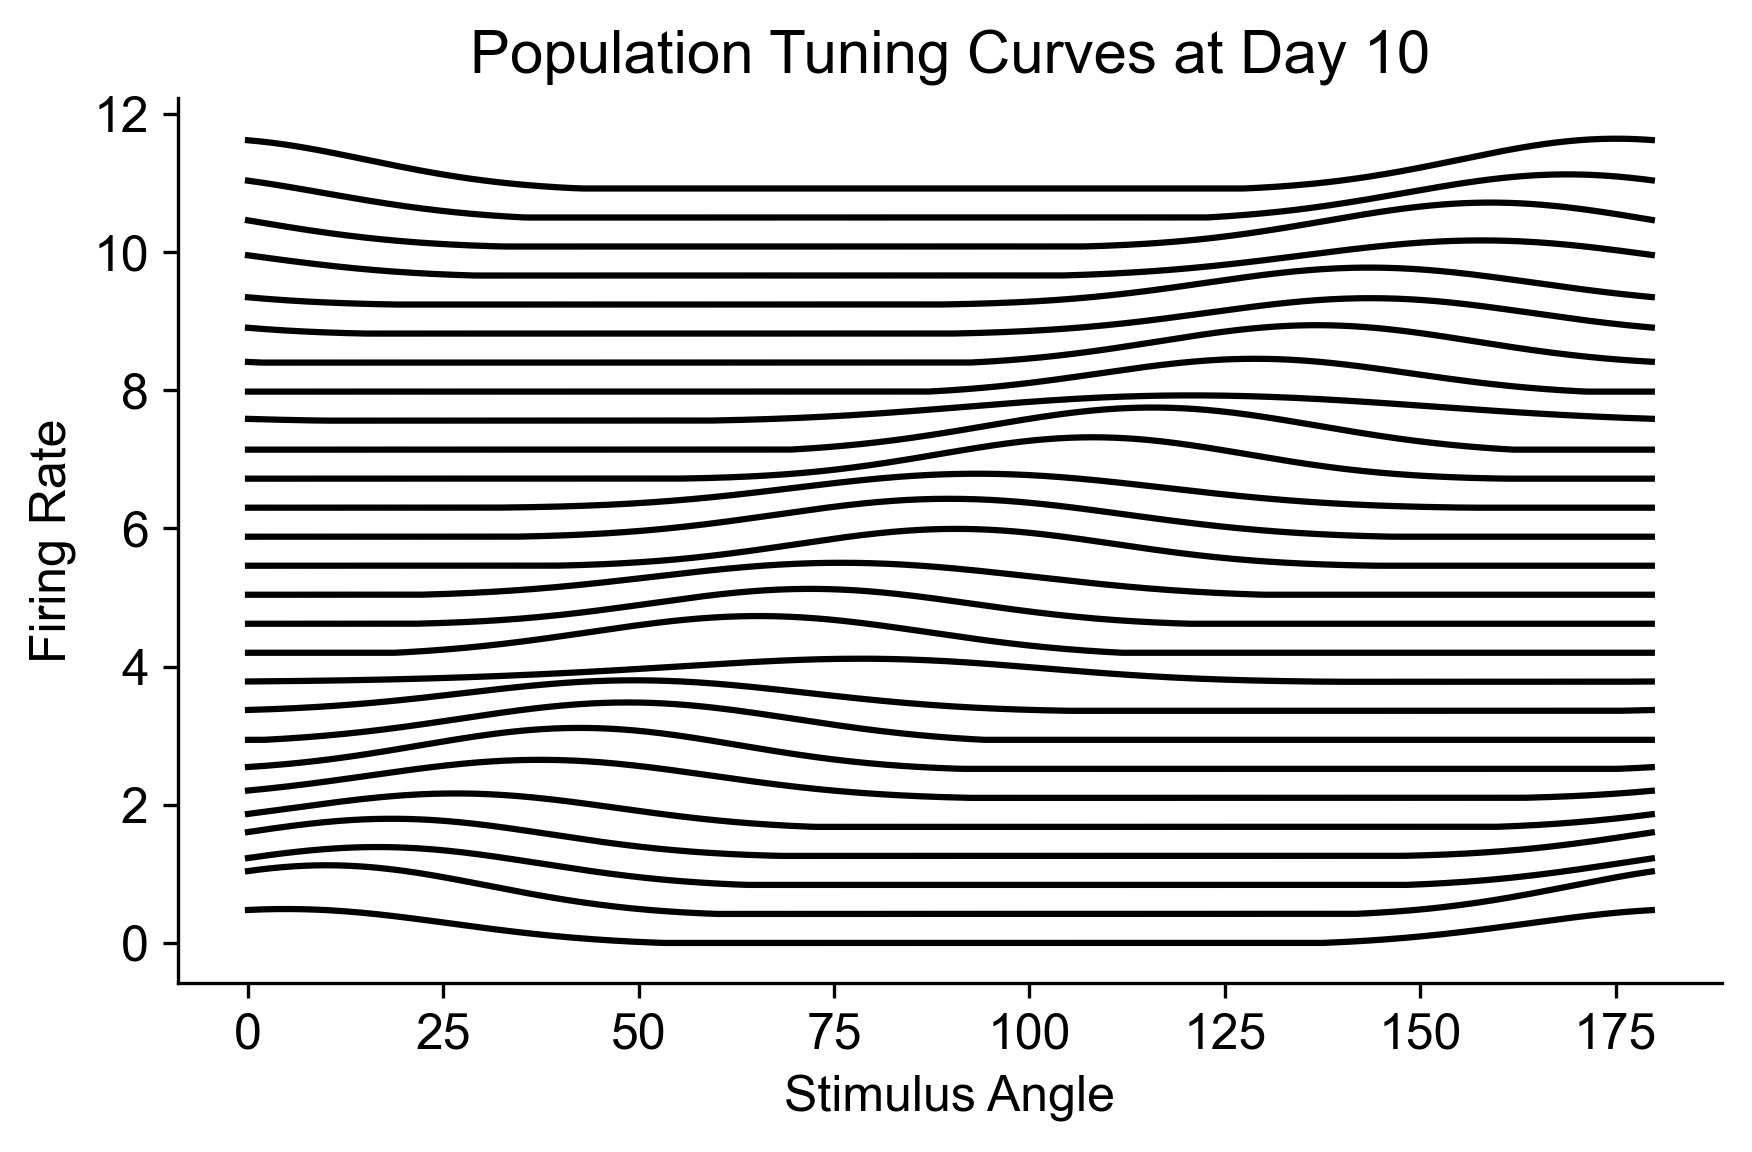

In [8]:
net.inh_scale_timeline = np.ones(net.n_days)
net.plot_population_tuning_curves(10)

In [9]:
from helper_functions import circular_gaussian


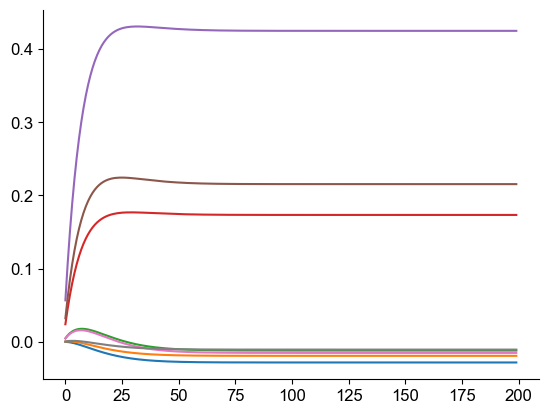

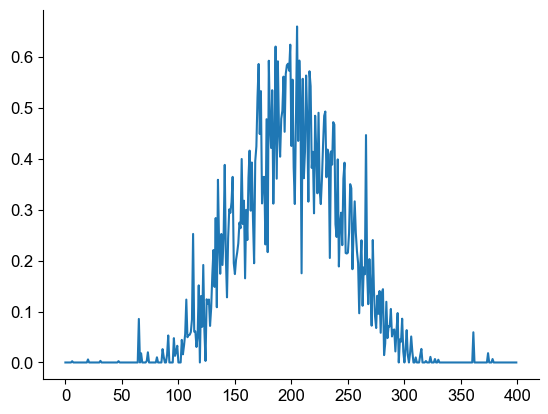

In [10]:
u_E_traj = np.zeros((net.T_seq, net.N))
net.setup_variables()
net.r_F = circular_gaussian(net.N, 90, amp=0.62, sigma=net.input_sigma)
for t in range(net.T_seq):
    net.step()
    u_E_traj[t] = net.u_E.copy()
plt.plot(u_E_traj[:, ::50])  # first 10 neurons
plt.show()
plt.figure()
plt.plot(net.r_E)

  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [03:04<00:00,  2.71it/s]

Silent neurons: 0 / 400
Near-silent (peak < 0.01): 0 / 400


Text(0.5, 1.0, 'Distribution of peak activity')

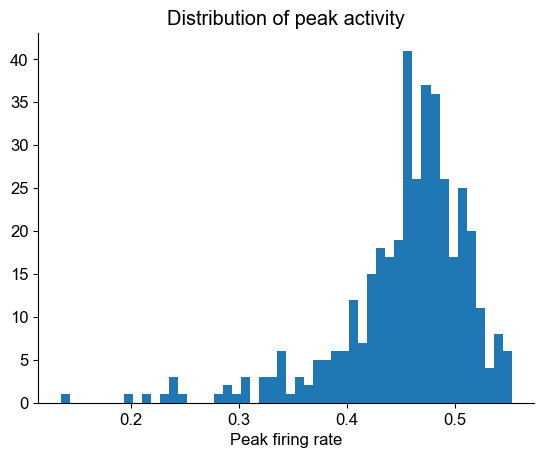

In [ ]:
tuning_curves, _ = net.estimate_tuning_curves_at_day(0)
peak_activity = np.max(tuning_curves, axis=1)
print(f"Silent neurons: {np.sum(peak_activity == 0)} / {net.N}")
print(f"Near-silent (peak < 0.01): {np.sum(peak_activity < 0.01)} / {net.N}")
plt.hist(peak_activity, bins=50)
plt.xlabel("Peak firing rate"); plt.title("Distribution of peak activity")

In [ ]:
tuning_curves, _ = net.estimate_tuning_curves_at_day(0)
n_silent = np.sum(np.max(tuning_curves, axis=1) == 0)
print(f"Silent neurons: {n_silent} / {net.N}")

100%|██████████| 500/500 [03:05<00:00,  2.69it/s]

Silent neurons: 0 / 400
